In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import k_means
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

In [2]:
df=pd.read_csv("animal_species.csv")
df

,animal_id,weight_kg,height_cm,habitat,diet_type,species
0,1,184.0,108.8,Savanna,Carnivore,Lion
1,2,978.9,540.6,Grassland,Herbivore,Giraffe
2,3,154.7,121.5,Savanna,Carnivore,Lion
3,4,5860.5,265.1,Savanna,Herbivore,Elephant
4,5,4206.9,337.1,Forest,Herbivore,Elephant
...,...,...,...,...,...,...
195,196,834.7,541.9,Grassland,Herbivore,Giraffe
196,197,73.6,83.3,Forest,Carnivore,Wolf
197,198,1.3,28.6,Grassland,Herbivore,Rabbit
198,199,2.6,21.7,Forest,Herbivore,Rabbit


<Axes: xlabel='height_cm', ylabel='weight_kg'>

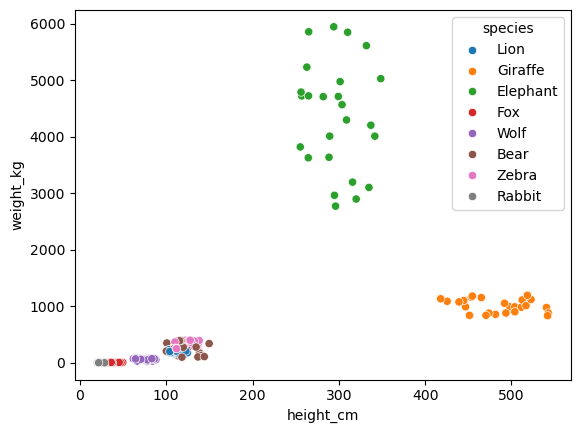

In [3]:
sns.scatterplot(x="height_cm",y="weight_kg",data=df,hue="species")

In [4]:
#This KmeanCluster can only used for numerical columns only
print("Shape of the dataset:", df.shape)
print("\nColumn names:")
print(df.columns)
print("\nDataset information:")
df.info()

Shape of the dataset: (200, 6)

Column names:
Index(['animal_id', 'weight_kg', 'height_cm', 'habitat', 'diet_type',
       'species'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   animal_id  200 non-null    int64  
 1   weight_kg  200 non-null    float64
 2   height_cm  200 non-null    float64
 3   habitat    200 non-null    object 
 4   diet_type  200 non-null    object 
 5   species    200 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 9.5+ KB


In [5]:
df.isnull().sum()

animal_id    0
weight_kg    0
height_cm    0
habitat      0
diet_type    0
species      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

<Axes: ylabel='height_cm'>

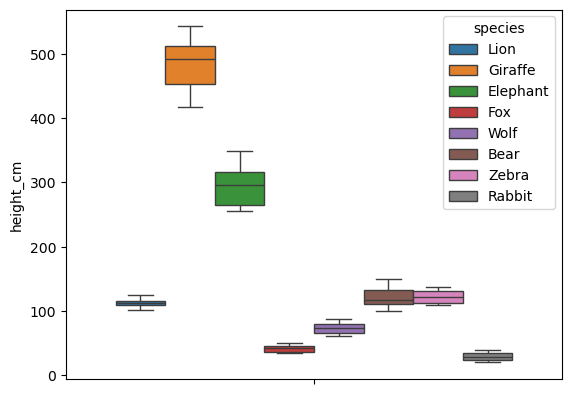

In [7]:
sns.boxplot(y="height_cm",hue="species",data=df)

In [8]:
X=df[["height_cm","weight_kg"]]
X

,height_cm,weight_kg
0,108.8,184.0
1,540.6,978.9
2,121.5,154.7
3,265.1,5860.5
4,337.1,4206.9
...,...,...
195,541.9,834.7
196,83.3,73.6
197,28.6,1.3
198,21.7,2.6


In [9]:
scaler = StandardScaler()
X_scaled= scaler.fit_transform(X)

In [13]:
model = KMeans(n_clusters=5, random_state=42, n_init=10)
model.fit(X_scaled)

,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [23]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

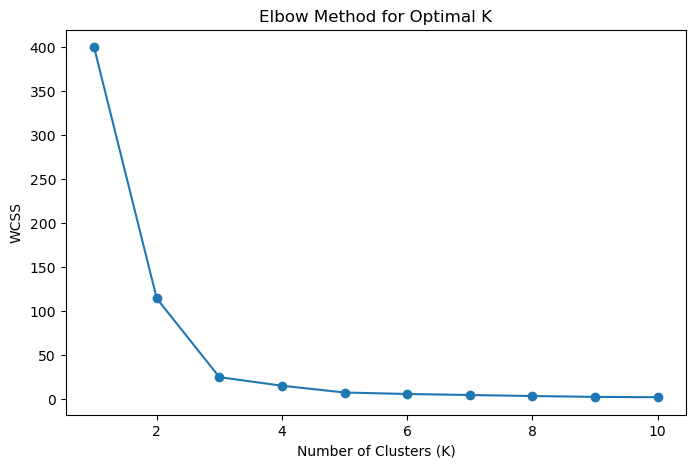

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

In [34]:
#By the above graph we know that at k=3 it is good elbow
model=KMeans(
             n_clusters=3,
             random_state=42,
             n_init=10)
model.fit(X_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [35]:
y_pred=model.predict(X_scaled)
y_pred

array([0, 1, 0, 2, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 2, 0, 0, 0, 0, 1, 2, 0,
       2, 2, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0,
       0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 2, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 1, 2, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 2, 0, 2, 2, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 2], dtype=int32)

In [31]:
df['Cluster']= y_pred
df.head()

,animal_id,weight_kg,height_cm,habitat,diet_type,species,Cluster
0,1,184.0,108.8,Savanna,Carnivore,Lion,0
1,2,978.9,540.6,Grassland,Herbivore,Giraffe,1
2,3,154.7,121.5,Savanna,Carnivore,Lion,0
3,4,5860.5,265.1,Savanna,Herbivore,Elephant,2
4,5,4206.9,337.1,Forest,Herbivore,Elephant,2


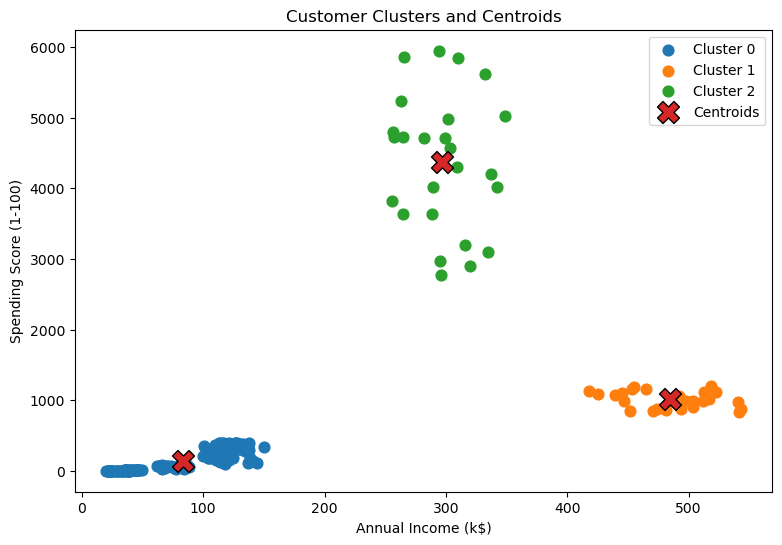

In [ ]:
centroids_original= scaler.inverse_transform(model.cluster_centers_)
plt.figure(figsize=(9, 6))
for cluster in sorted(df['Cluster'].unique()):
    cluster_data= df[df['Cluster']== cluster]
    plt.scatter(
    cluster_data['height_cm'],
    cluster_data['weight_kg'],
    label=f'Cluster {cluster}',
    s=60
    )
plt.scatter(
centroids_original[:, 0],
centroids_original[:, 1],
marker='X',
s=250,
edgecolors='black',
label='Centroids'
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Clusters and Centroids")
plt.legend()
plt.show()

In [37]:
model=KMeans(n_clusters=8,random_state=42,n_init=2)
model.fit(X_scaled)

,n_clusters,8
,init,'k-means++'
,n_init,2
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [38]:
y_pred=model.predict(X_scaled)

In [41]:
df["Cluster"]=y_pred

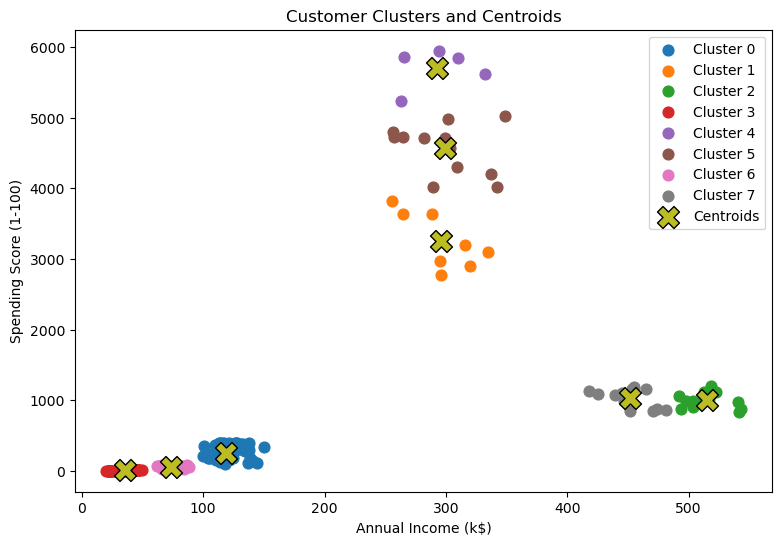

In [42]:
centroids_original= scaler.inverse_transform(model.cluster_centers_)
plt.figure(figsize=(9, 6))
for cluster in sorted(df['Cluster'].unique()):
    cluster_data= df[df['Cluster']== cluster]
    plt.scatter(
    cluster_data['height_cm'],
    cluster_data['weight_kg'],
    label=f'Cluster {cluster}',
    s=60
    )
plt.scatter(
centroids_original[:, 0],
centroids_original[:, 1],
marker='X',
s=250,
edgecolors='black',
label='Centroids'
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Clusters and Centroids")
plt.legend()
plt.show()

<Axes: xlabel='height_cm', ylabel='weight_kg'>

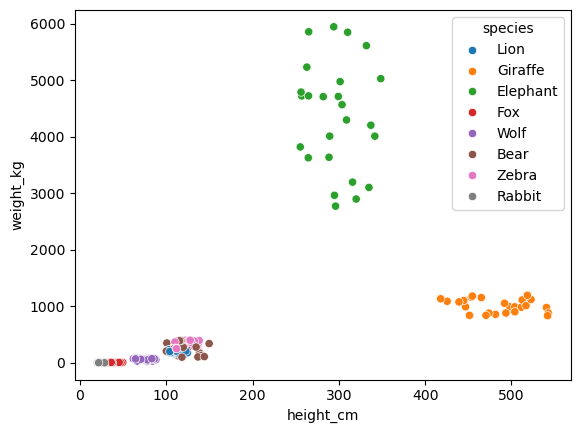

In [45]:
sns.scatterplot(x="height_cm",y="weight_kg",data=df,hue="species")

In [ ]:
#from the above two we can decide by using the elbow plot so that 
#k=3 is the best value to use it
